In [1]:
from scapyter.domain.analysis.tvla.incremental_evaluator import TvlaIncrementalEvaluator
from scapyter.domain.analysis.tvla.service import TvlaService
import pandas as pd
from scapyter.domain.value_object import RangeParameters, Range
from scapyter.infrastructure.h5_project_file_reader import H5ProjectFileReader

file_path = "tvla_example.h5"

with H5ProjectFileReader(file_path) as repo:
    range_parameter = RangeParameters(
        trace_range=Range(0, 500),
        sample_range=Range(0, repo.sample_count),
    )
    service = TvlaService(project_file_reader=repo, range_parameters=range_parameter)

    stepper = TvlaIncrementalEvaluator(service)

    t_map = stepper.run_steps(step_size=50)

df = pd.DataFrame(list(t_map.items()), columns=["trace_count", "max_t_score"])
df.to_csv("tvla_results.csv", index=False)

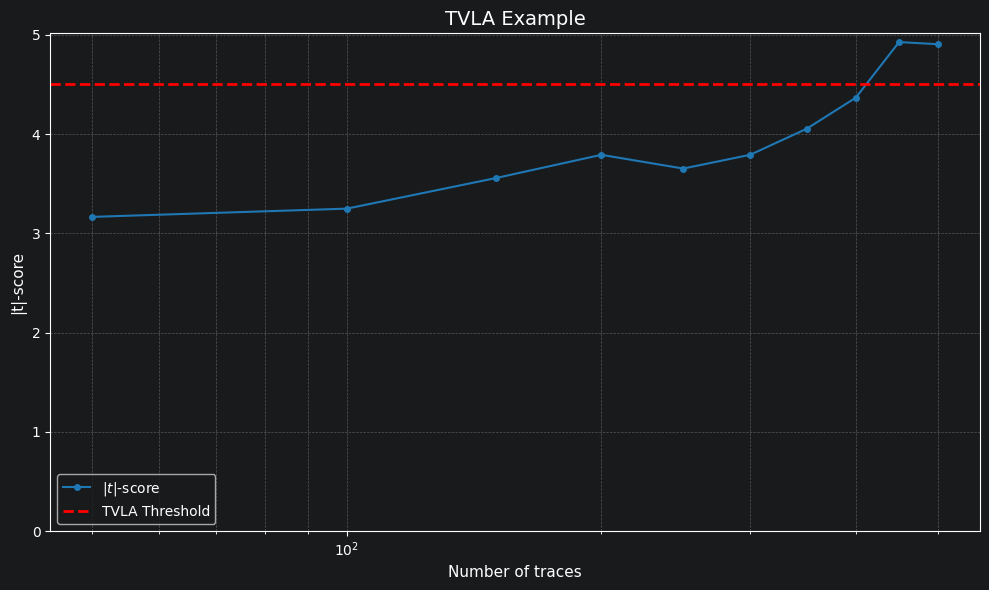

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("tvla_results.csv")

# 2. Sort to ensure the line doesn't jump backwards
df = df.sort_values("trace_count")

plt.figure(figsize=(10, 6))

# 1. Plot the absolute values
plt.plot(
    df["trace_count"],
    df["max_t_score"],
    marker="o",
    markersize=4,
    color="tab:blue",
    label="$|t|$-score",
)

# 2. Set Log Scale
plt.xscale("log")

# 3. Single Threshold Line
plt.axhline(y=4.5, color="red", linestyle="--", linewidth=2, label="TVLA Threshold")

# 4. Adjust Y-axis to start at 0
# This prevents the plot from "floating" and makes the scale clearer
plt.ylim(bottom=0)

# 5. Formatting
plt.title("TVLA Example", fontsize=14)
plt.xlabel("Number of traces", fontsize=11)
plt.ylabel("|t|-score", fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()